## Consigna Práctica - Comunicaciones Digitales

Con el fin de caracterizar el ruido presente en todo canal de comunicaciones inalámbrico se pide realizar un código en una Jupyter notebook que permita extraer las componentes en fase (parte real) y en cuadratura (parte imaginaria) de la señal recibida por el receptor del SDR cuando el mismo no se encuentra transmitiendo ningún tipo de señal. Algunas de las configuraciones necesarias para esta experiencia son:

- **Uri = "ip:192.168.1.34"** #También puede ser "ip:192.168.1.35", "ip:192.168.1.32" o "ip:192.168.1.33"
- **Loopback = 0**
- **Tx_cyclic_buffer = False**
- **TxAtten = -70**
- **GainControlModes = "manual"**
- **RxHardwareGain = 70**
- **RxBufferSize = 2\*\*20**

en donde los demás parámetros sin especificar pueden ser elegidos por el usuario.

Bajo estas condiciones se va a poder "escuchar" el canal con la mínima interferencia posible.

Con las muestras obtenidas en las componentes en fase y cuadratura, se pide:

1. Graficar la señal en tiempo y en frecuencia.
2. Obtener la media y la varianza.
3. Realizar un histograma (Ver página 485 del libro "Intro a los sist. de comunicación").
4. Normalizar el histograma para que el área encerrada sea igual a 1.
5. Superponer el histograma normalizado con una función de densidad de probabilidad (PDF) gaussiana teórica.
6. Analizar la gaussianidad mediante un gráfico Q-Q haciendo uso de la función propia de python "qqplot".
7. Generar mediante un código, una variable gaussiana compleja que tenga la misma media y varianza que la señal muestreada y obtener su gráfica temporal, su gráfica en frecuencia y su histograma.

Escriba al final de la jupyter notebook una conclusión respecto a los resultados obtenidos en la práctica. Adjuntar la Jupyter Notebook que permitió obtener todos estos resultados.

In [1]:
import adi
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from statsmodels.graphics.gofplots import qqplot

## Fución Para Gráficar Las Señales

In [2]:
def plotSignal(signal):
    # Configura una única figura para todos los subplots
    plt.figure(figsize=(20, 16), dpi=80, facecolor="w", edgecolor="k")
    
    #------------------------------- Componente I transmitida -------------------------------
    # Grafico la componente I en el tiempo
    plt.subplot(4, 1, 1)
    plt.plot(np.real(signal))
    plt.xlabel("n")
    plt.ylabel("Amplitud")
    plt.title("Componente en fase de la señal")
    plt.grid()
    
    # Grafico la componente I en la frecuencia
    # Se hace uso de magnitude_spectrum y del samplerate utilizado por el SDR
    plt.subplot(4, 1, 2)
    plt.magnitude_spectrum(np.real(signal), scale="dB", Fs=samplerate)
    plt.title("Espectro de Frecuencia de la Componente I")
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud (dB)")
    plt.grid()
    
    #------------------------------- Componente Q transmitida -------------------------------
    # Grafico la componente Q en el tiempo
    plt.subplot(4, 1, 3)
    plt.plot(np.imag(signal))
    plt.xlabel("n")
    plt.ylabel("Amplitud")
    plt.title("Componente en cuadratura de la señal")
    plt.grid()
    
    # Grafico la componente Q en la frecuencia
    # Se hace uso de magnitude_spectrum y del samplerate utilizado por el SDR
    plt.subplot(4, 1, 4)
    plt.magnitude_spectrum(np.imag(signal), scale="dB", Fs=samplerate)
    plt.title("Espectro de Frecuencia de la Componente Q")
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud (dB)")
    plt.grid()
    
    # Mostrar los graficos
    plt.tight_layout()
    plt.show()

In [3]:
def histograma(signal, median, var):
    plt.figure(figsize=(10, 4))
    # Grafica el histograma normalizado mediante el parametro density=True
    count_real, bins_real, ignored_real = plt.hist(signal, bins=100, density=True, alpha=0.6, color="g", label="Real")
    # Calcula la funcion PDF gaussiana teórica
    pdf_real = norm.pdf(bins_real, median, np.sqrt(var))
    plt.plot(bins_real, pdf_real, linewidth=2, color="b", label="Teórica")
    plt.title("Histograma parte Real")
    plt.legend()
    plt.grid()
    plt.show()

In [4]:
def media_var(signal):
    media = np.mean(signal)
    var = np.var(signal)
    return media, var
    

In [5]:
def qq_plot(signal, parte):
    qqplot(signal, line="s")
    plt.title("Gráfico Q-Q - Parte " + parte)
    plt.show()

In [6]:
def real_imag(signal):
    return np.real(signal), np.imag(signal)
    

In [7]:
# Configuración inicial del SDR
uri = "ip:192.168.1.34" 
sdr = adi.Pluto(uri)
sdr.loopback = 0
sdr.tx_cyclic_buffer = False
sdr.tx_hardwaregain_chan0 = -70
sdr.gain_control_mode_chan0 = "manual"
sdr.rx_hardwaregain_chan0 = 70
sdr.rx_buffer_size = 2**20
samplerate = sdr.sample_rate

In [8]:
# Captura las señales
rx_signal = sdr.rx()  

In [9]:
# Extrae las componentes en fase (I) y en cuadratura (Q)
I, Q = real_imag(rx_signal)

## 1. Graficar la señal en tiempo y en frecuencia

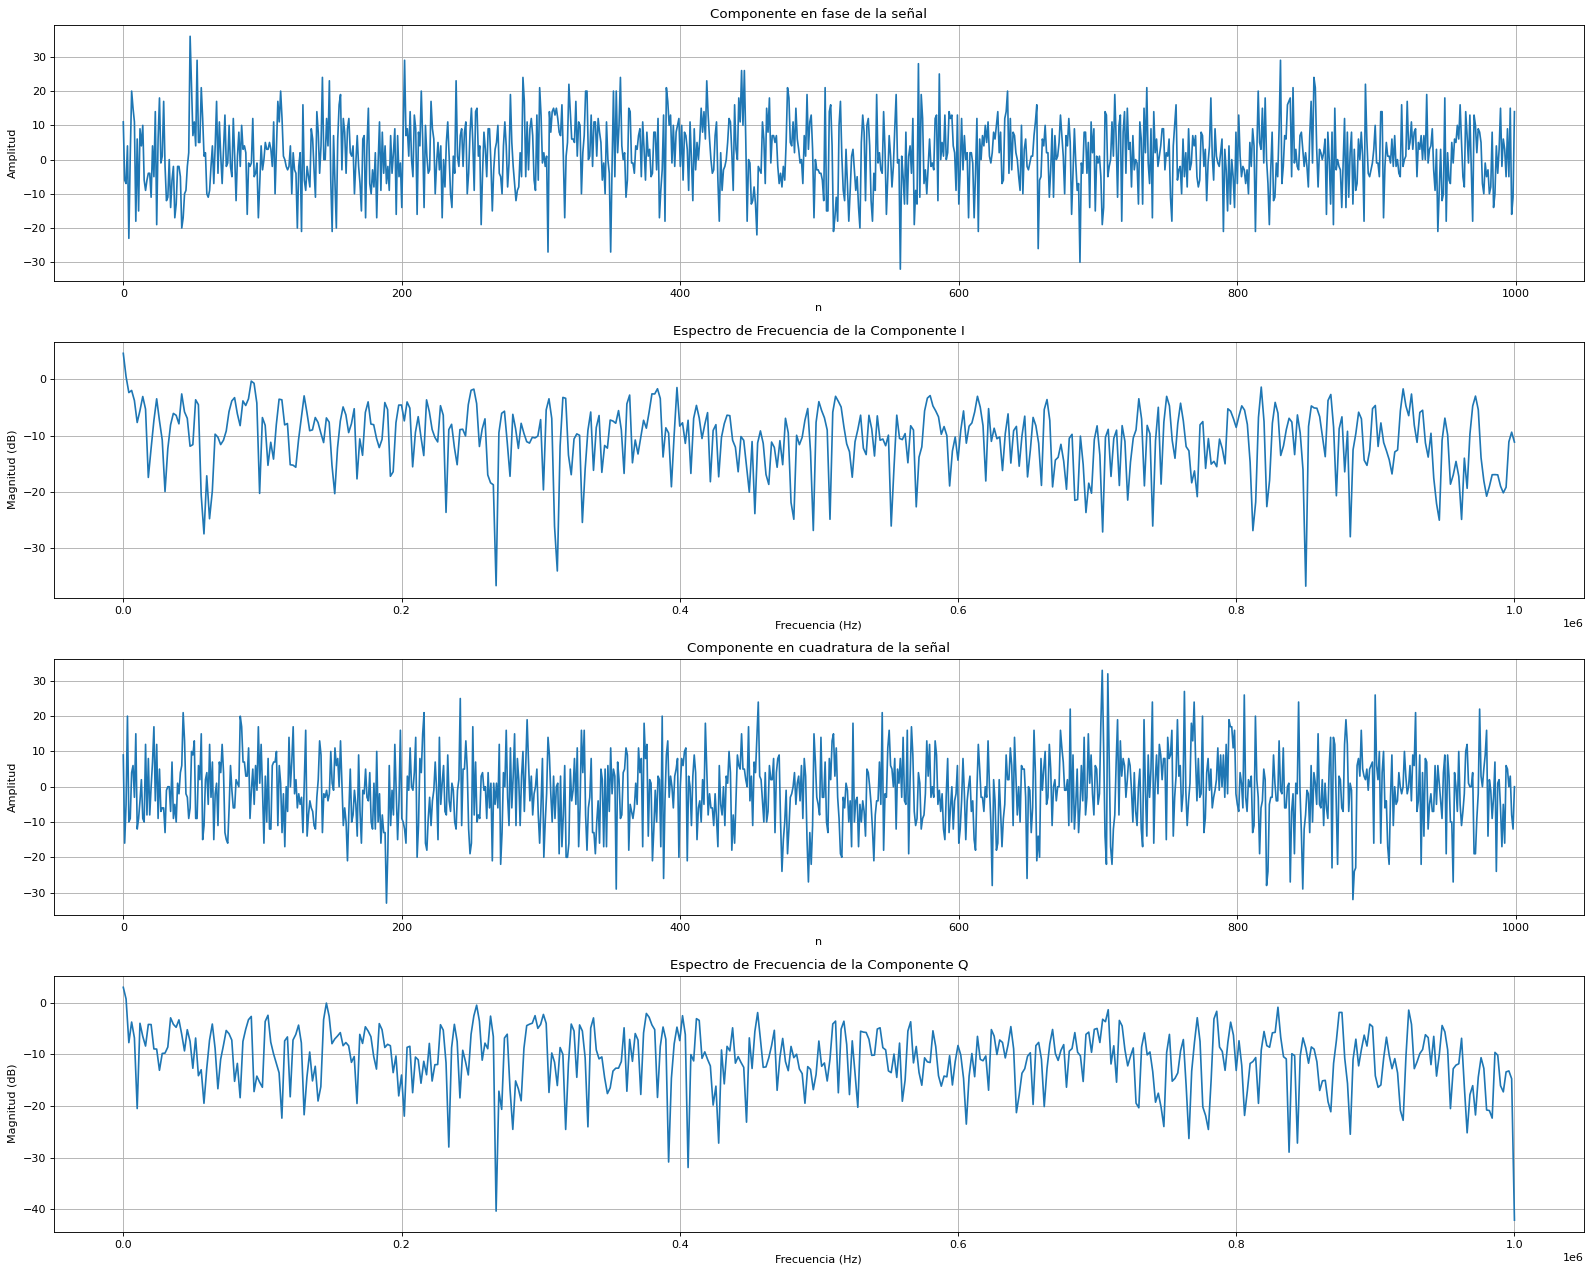

In [10]:
# Grafica las señales en el tiempo y en la frecuencia
plotSignal(rx_signal[:1000])

## 2. Obtener la media y la varianza

In [11]:
# Calcula la media y la varianza para I y Q
media_I, var_I = media_var(I)
media_Q, var_Q = media_var(Q)
print("Media Y Varianza De I\n")
print("Media_I = " + str(media_I) ,"\nVar_I = " + str(var_I))
print("\nMedia Y Varianza De Q\n")
print("Media_Q = " + str(media_Q),"\nVar_Q = " + str(var_Q))

Media Y Varianza De I

Media_I = 0.0029001235961914062 
Var_I = 109.00048654625297

Media Y Varianza De Q

Media_Q = 0.0027933120727539062 
Var_Q = 109.23677903975349


## 3. Realizar un histograma
## 4. Normalizar el histograma para que el área encerrada sea igual a 1.
## 5. Superponer el histograma normalizado con una función de densidad de probabilidad (PDF) gaussiana teórica.

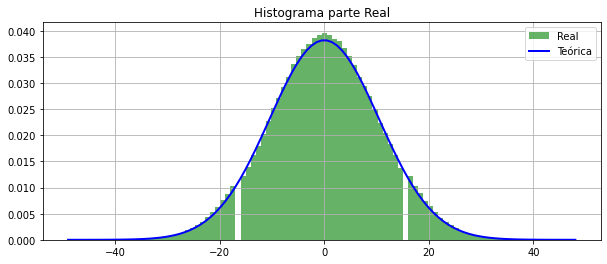

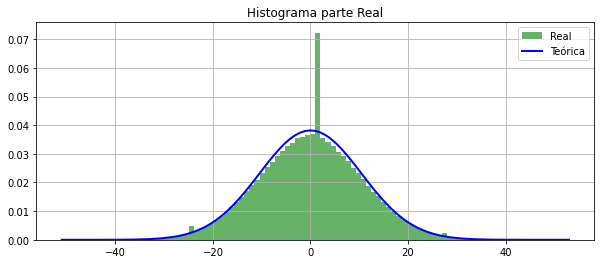

In [12]:
histograma(I, media_I, var_I)
histograma(Q, media_Q, var_Q)


## 6. Analizar la gaussianidad mediante un gráfico Q-Q haciendo uso de la función propia de python "qqplot"

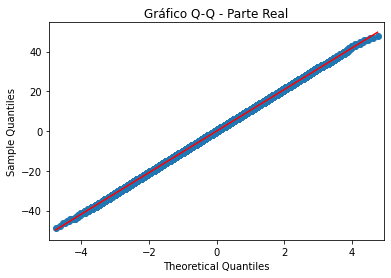

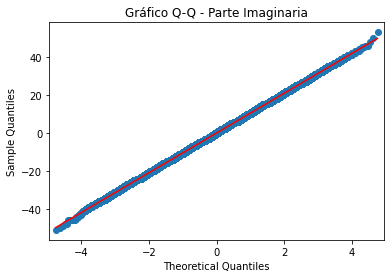

In [13]:
# Compara los datos obtenidos en I con la función normal teorica estandar en un grafico del tipo Q-Q
qq_plot(I, "Real")
# Compara los datos obtenidos en Q con la función normal teorica estandar en un grafico del tipo Q-Q
qq_plot(Q, "Imaginaria")

## 7. Generar mediante un código, una variable gaussiana compleja que tenga la misma media y varianza que la señal muestreada y obtener su gráfica temporal, su gráfica en frecuencia y su histograma

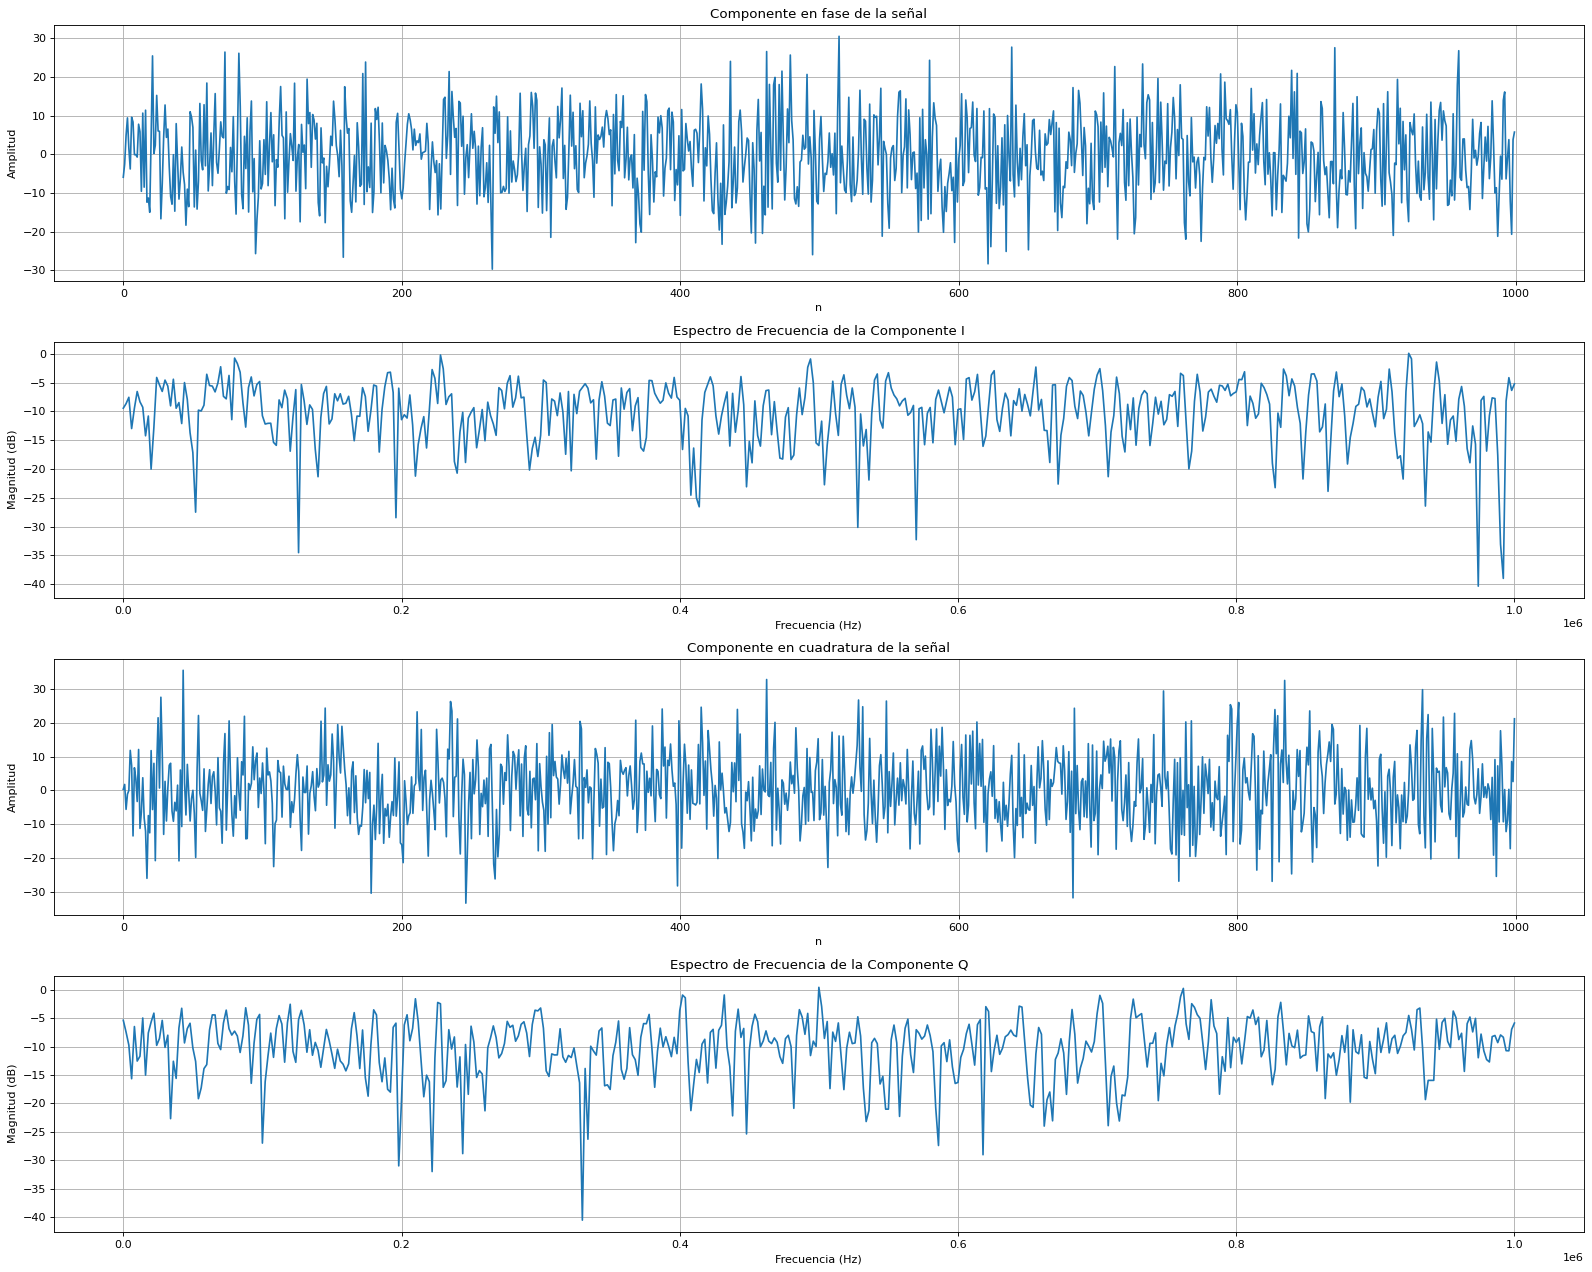

In [14]:
# Crea una función gaussiana compleja con los mismos parametros medidos anteriormente
gaussian_signal = np.random.normal(media_I, np.sqrt(var_I), len(I)) + 1j * np.random.normal(media_Q, np.sqrt(var_Q), len(Q))
G_I, G_Q = real_imag(gaussian_signal)

# Utiliza el metodo plotsignal() para realizar la gráfica de la función gaussiana compleja anteriormente definida
plotSignal(gaussian_signal[:1000])

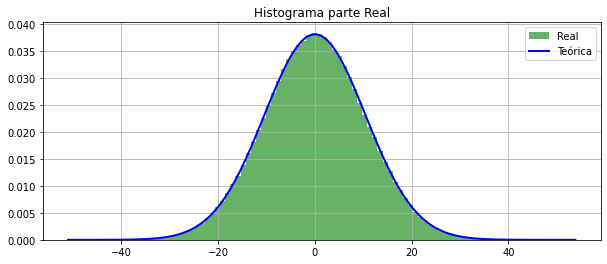

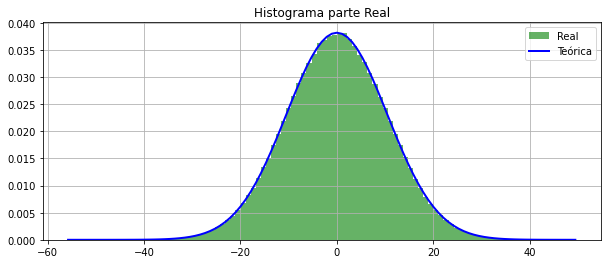

In [15]:
histograma(G_I, np.mean(G_I), np.var(G_I))
histograma(G_Q, np.mean(G_Q), np.var(G_Q))

## 8. Conclusión

El análisis de las señales recibidas por el receptor SDR, en ausencia de señales activas, resultó ser fundamental para comprender el fenómeno del ruido y su caracterización a través del software. Un aspecto observado durante este estudio fue la variación de la señal recibida debido a perturbaciones diurnas, lo cual influía en que el histograma normalizado se asemejara en mayor o menor medida a una distribución de probabilidad gaussiana teórica. De esto se infirió que la noche es el mejor periodo para minimizar dichas perturbaciones.

Además, este trabajo permitió reconocer la importancia de los histogramas y los gráficos Q-Q como herramientas esenciales para la comparación de distribuciones. Esta conclusión emergió debido a que las gráficas de tiempo y frecuencia, tanto teoricas como las creadas utilizando las muestras reales, son complejas de comparar entre sí.

Finalmente, mediante el análisis de mediciones realizadas a las 23 horas, se determinó que las muestras de ruido estudiadas se ajustan a una distribución gaussiana. 